In [17]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sqlite3


In [18]:
conn=sqlite3.connect('Customer_Churn.db')

In [19]:
sql_query="""
        select name
        from sqlite_master
        where type='table';
"""

In [20]:
tables=pd.read_sql(sql_query,conn)

In [21]:
for table_name in tables['name']:
    df=pd.read_sql(f"select * from {table_name}",conn)
    globals()[f"df_{table_name}"]=df
    print(f"Created dataframe:df_{table_name}")
    
conn.close()    
    

In [22]:
conn=sqlite3.connect('Customer_Churn.db')

for table_name in tables['name']:
    print(f"\nTable Name: {table_name}")
    
    columns_query=f"PRAGMA table_info({table_name}):"
    columns=pd.read_sql(columns_query,conn)
    print("Columns:")
    print(columns['name'].tolist())
    
conn.close()    

In [58]:
customer=pd.read_csv("C:/Users/ASUS/Documents/customer.csv")
customer

,customerid,name,country,state,gender,dob,interests,pincode
0,0002-ORFBO,keshav,India,Maharashtra,Male,12/04/1982,travel,NaN
1,0003-MKNFE,raghav,India,Karnataka,Male,23/11/1995,NaN,NaN
2,0004-TLHLJ,lalita,India,Delhi,Female,15/02/1978,movie,NaN
3,0011-IGKFF,mohan,India,Nagaland,Male,30/08/2001,NaN,NaN
4,0013-EXCHZ,mira,India,Delhi,Female,05/05/1990,drama,NaN
5,0013-MHZWF,durga,NaN,Delhi,Women,10/12/1988,NaN,NaN
6,0013-SMEOE,mina,India,Meghalaya,Female,21/09/1976,NaN,NaN
7,0014-BMAQU,madan,India,Rajasthan,Male,14/03/1999,NaN,NaN
8,0015-UOCOJ,maya,NaN,Kathmandu,Women,07/07/1985,NaN,NaN
9,0016-QLJIS,arjun,Nepal,Kathmandu,Male,29/10/1993,NaN,NaN


In [29]:
subscription= pd.read_csv("C:/Users/ASUS/Documents/subscription.csv")
subscription

,customerid,subscription_start_date,subscription_type,renewal_date,plan_type,contract_type,cancellation_date,cancellation_reason,monthly_charges,cltv,churn_score
0,0002-ORFBO,2021-03-15,Refferal,2025-03-15,Standard,Annual,NaN,NaN,13.99,627,12
1,0003-MKNFE,2020-08-01,Paid,2024-08-01,Premium,Annual,2024-09-10,Switched to competitor,12.99,1150,91
2,0004-TLHLJ,2022-11-20,Organic,2025-11-20,Basic,Monthly,NaN,NaN,6.99,210,34
3,0011-IGKFF,2019-05-10,Paid,2025-05-10,Premium,Annual,NaN,NaN,22.99,1725,8
4,0013-EXCHZ,2023-01-05,Refferal,2024-01-05,Standard,Monthly,2024-02-28,Too expensive,13.99,195,88
5,0013-MHZWF,2022-06-18,Paid,2025-06-18,Standard,Annual,NaN,NaN,17.99,720,22
6,0013-SMEOE,2021-09-30,Refferal,2024-09-30,Basic,Monthly,2024-11-15,Not enough content,8.99,230,79
7,0014-BMAQU,2020-02-14,Organic,2025-02-14,Premium,Annual,NaN,NaN,22.99,1840,5
8,0015-UOCOJ,2023-07-22,Organic,2024-07-22,Standard,Monthly,NaN,NaN,13.99,240,34
9,0016-QLJIS,2022-04-03,Organic,2025-04-03,Basic,Annual,NaN,NaN,6.99,335,41


In [31]:
support= pd.read_csv("C:/Users/ASUS/Documents/support.csv")
support

,customerid,complaint_date,escalations,csat_score,col_1,comment
0,0003-MKNFE,28/08/2024,N,60,NaN,service issue
1,0003-MKNFE,28/08/2024,Y,10,NaN,demaned refund
2,0013-EXCHZ,20/01/2024,Y,20,NaN,NaN
3,0013-MHZWF,18/03/2025,N,90,NaN,guidance to renew
4,0013-SMEOE,01/11/2024,N,30,NaN,NaN
5,0017-IUDMW,10/04/2024,Y,25,NaN,NaN
6,0019-EFAEP,27/09/2024,Y,30,NaN,NaN
7,0022-TCJCI,13/09/2024,Y,10,NaN,NaN
8,0022-TCJCI,14/09/2024,N,90,NaN,received refund


In [59]:
customer.head()

,customerid,name,country,state,gender,dob,interests,pincode
0,0002-ORFBO,keshav,India,Maharashtra,Male,12/04/1982,travel,NaN
1,0003-MKNFE,raghav,India,Karnataka,Male,23/11/1995,NaN,NaN
2,0004-TLHLJ,lalita,India,Delhi,Female,15/02/1978,movie,NaN
3,0011-IGKFF,mohan,India,Nagaland,Male,30/08/2001,NaN,NaN
4,0013-EXCHZ,mira,India,Delhi,Female,05/05/1990,drama,NaN


In [60]:
customer.tail()

,customerid,name,country,state,gender,dob,interests,pincode
17,0021-IKXGC,vishakha,India,Rajasthan,Female,02/09/2000,NaN,NaN
18,0022-TCJCI,raghvendra,India,Telangana,Male,30/12/1983,NaN,NaN
19,0023-HGHWL,rishabh,India,Uttar Pradesh,Men,14/05/1991,NaN,NaN
20,0023-UYUPN,sudevi,India,Maharashtra,Women,06/10/1977,NaN,NaN
21,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [61]:
customer.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 22 entries, 0 to 21
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   customerid  21 non-null     object 
 1   name        21 non-null     object 
 2   country     18 non-null     object 
 3   state       21 non-null     object 
 4   gender      21 non-null     object 
 5   dob         21 non-null     object 
 6   interests   4 non-null      object 
 7   pincode     0 non-null      float64
dtypes: float64(1), object(7)
memory usage: 1.5+ KB


In [ ]:
# Data Cleaning

In [62]:
# Rename column
customer.rename(columns={'name':'customer_name'},inplace=True)
customer

,customerid,customer_name,country,state,gender,dob,interests,pincode
0,0002-ORFBO,keshav,India,Maharashtra,Male,12/04/1982,travel,NaN
1,0003-MKNFE,raghav,India,Karnataka,Male,23/11/1995,NaN,NaN
2,0004-TLHLJ,lalita,India,Delhi,Female,15/02/1978,movie,NaN
3,0011-IGKFF,mohan,India,Nagaland,Male,30/08/2001,NaN,NaN
4,0013-EXCHZ,mira,India,Delhi,Female,05/05/1990,drama,NaN
5,0013-MHZWF,durga,NaN,Delhi,Women,10/12/1988,NaN,NaN
6,0013-SMEOE,mina,India,Meghalaya,Female,21/09/1976,NaN,NaN
7,0014-BMAQU,madan,India,Rajasthan,Male,14/03/1999,NaN,NaN
8,0015-UOCOJ,maya,NaN,Kathmandu,Women,07/07/1985,NaN,NaN
9,0016-QLJIS,arjun,Nepal,Kathmandu,Male,29/10/1993,NaN,NaN


In [70]:
# Drop columns
customer.drop(customer.columns[-2:],axis=1,inplace=True)
#customer.drop(columns=['interests','pincode'])

In [71]:
customer

,customerid,customer_name,country,state,gender,dob
0,0002-ORFBO,keshav,India,Maharashtra,Male,12/04/1982
1,0003-MKNFE,raghav,India,Karnataka,Male,23/11/1995
2,0004-TLHLJ,lalita,India,Delhi,Female,15/02/1978
3,0011-IGKFF,mohan,India,Nagaland,Male,30/08/2001
4,0013-EXCHZ,mira,India,Delhi,Female,05/05/1990
5,0013-MHZWF,durga,NaN,Delhi,Women,10/12/1988
6,0013-SMEOE,mina,India,Meghalaya,Female,21/09/1976
7,0014-BMAQU,madan,India,Rajasthan,Male,14/03/1999
8,0015-UOCOJ,maya,NaN,Kathmandu,Women,07/07/1985
9,0016-QLJIS,arjun,Nepal,Kathmandu,Male,29/10/1993


In [77]:
# Change datatype
customer['dob']= pd.to_datetime(customer['dob'])

In [80]:
# Data standardization
customer['gender'].replace({'Men':'Male','Women':'Female'},inplace=True)

In [81]:
customer['gender'].unique()

array(['Male', 'Female', nan], dtype=object)

In [82]:
# Fix Missing values
customer['country'].isna()

0     False
1     False
2     False
3     False
4     False
5      True
6     False
7     False
8      True
9     False
10    False
11    False
12     True
13    False
14    False
15    False
16    False
17    False
18    False
19    False
20    False
21     True
Name: country, dtype: bool

In [83]:
customer[customer['country'].isna()]

,customerid,customer_name,country,state,gender,dob
5,0013-MHZWF,durga,NaN,Delhi,Female,1988-10-12
8,0015-UOCOJ,maya,NaN,Kathmandu,Female,1985-07-07
12,0018-NYROU,chitra,NaN,Telangana,Female,2004-01-12
21,NaN,NaN,NaN,NaN,NaN,NaT


In [89]:
state_country_mapping= customer.dropna(subset=['country']).set_index('state')['country'].to_dict()
customer['country']=customer['country'].fillna(customer['state'].map(state_country_mapping))

In [93]:
customer[customer['country'].isna()]

,customerid,customer_name,country,state,gender,dob


In [94]:
subscription.head()

,customerid,subscription_start_date,subscription_type,renewal_date,plan_type,contract_type,cancellation_date,cancellation_reason,monthly_charges,cltv,churn_score
0,0002-ORFBO,2021-03-15,Refferal,2025-03-15,Standard,Annual,NaN,NaN,13.99,627,12
1,0003-MKNFE,2020-08-01,Paid,2024-08-01,Premium,Annual,2024-09-10,Switched to competitor,12.99,1150,91
2,0004-TLHLJ,2022-11-20,Organic,2025-11-20,Basic,Monthly,NaN,NaN,6.99,210,34
3,0011-IGKFF,2019-05-10,Paid,2025-05-10,Premium,Annual,NaN,NaN,22.99,1725,8
4,0013-EXCHZ,2023-01-05,Refferal,2024-01-05,Standard,Monthly,2024-02-28,Too expensive,13.99,195,88


In [95]:
subscription.tail()

,customerid,subscription_start_date,subscription_type,renewal_date,plan_type,contract_type,cancellation_date,cancellation_reason,monthly_charges,cltv,churn_score
16,0020-JDNXP,2022-01-19,Organic,2024-01-19,Premium,Annual,NaN,NaN,20.99,550,62
17,0021-IKXGC,2021-07-07,Paid,2025-07-07,Standard,Annual,NaN,NaN,13.99,840,27
18,0022-TCJCI,2023-09-14,Refferal,2024-09-14,Basic,Monthly,2024-09-14,Forgot to cancel trial,16.99,42,99
19,0023-HGHWL,2020-06-23,Organic,2025-06-23,Premium,Annual,NaN,NaN,22.99,1955,7
20,0023-UYUPN,2022-12-31,Paid,2025-12-31,Standard,Monthly,NaN,NaN,13.99,790,47


In [96]:
subscription.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21 entries, 0 to 20
Data columns (total 11 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   customerid               21 non-null     object 
 1   subscription_start_date  21 non-null     object 
 2   subscription_type        21 non-null     object 
 3   renewal_date             21 non-null     object 
 4   plan_type                21 non-null     object 
 5   contract_type            21 non-null     object 
 6   cancellation_date        6 non-null      object 
 7   cancellation_reason      6 non-null      object 
 8   monthly_charges          21 non-null     float64
 9   cltv                     21 non-null     int64  
 10  churn_score              21 non-null     int64  
dtypes: float64(1), int64(2), object(8)
memory usage: 1.9+ KB


In [99]:
date_col=['subscription_start_date','renewal_date','cancellation_date']
subscription[date_col]=subscription[date_col].apply(pd.to_datetime)
subscription.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21 entries, 0 to 20
Data columns (total 11 columns):
 #   Column                   Non-Null Count  Dtype         
---  ------                   --------------  -----         
 0   customerid               21 non-null     object        
 1   subscription_start_date  21 non-null     datetime64[ns]
 2   subscription_type        21 non-null     object        
 3   renewal_date             21 non-null     datetime64[ns]
 4   plan_type                21 non-null     object        
 5   contract_type            21 non-null     object        
 6   cancellation_date        6 non-null      datetime64[ns]
 7   cancellation_reason      6 non-null      object        
 8   monthly_charges          21 non-null     float64       
 9   cltv                     21 non-null     int64         
 10  churn_score              21 non-null     int64         
dtypes: datetime64[ns](3), float64(1), int64(2), object(5)
memory usage: 1.9+ KB


In [100]:
support.head()

,customerid,complaint_date,escalations,csat_score,col_1,comment
0,0003-MKNFE,28/08/2024,N,60,NaN,service issue
1,0003-MKNFE,28/08/2024,Y,10,NaN,demaned refund
2,0013-EXCHZ,20/01/2024,Y,20,NaN,NaN
3,0013-MHZWF,18/03/2025,N,90,NaN,guidance to renew
4,0013-SMEOE,01/11/2024,N,30,NaN,NaN


In [101]:
support.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9 entries, 0 to 8
Data columns (total 6 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   customerid      9 non-null      object 
 1   complaint_date  9 non-null      object 
 2   escalations     9 non-null      object 
 3   csat_score      9 non-null      int64  
 4   col_1           0 non-null      float64
 5   comment         4 non-null      object 
dtypes: float64(1), int64(1), object(4)
memory usage: 560.0+ bytes


In [102]:
support.drop(columns=['col_1','comment'],inplace=True)

In [104]:
support['complaint_date']=pd.to_datetime(support['complaint_date'])

In [105]:
support.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9 entries, 0 to 8
Data columns (total 4 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   customerid      9 non-null      object        
 1   complaint_date  9 non-null      datetime64[ns]
 2   escalations     9 non-null      object        
 3   csat_score      9 non-null      int64         
dtypes: datetime64[ns](1), int64(1), object(2)
memory usage: 416.0+ bytes


In [ ]:
# Feature Engineering(cloumn use,update columns,make new columns using existing columns) and Data Analysis

In [106]:
subscription['churn_flag']=np.where(subscription['cancellation_date'].notna(),1,0)

In [107]:
subscription.head()

,customerid,subscription_start_date,subscription_type,renewal_date,plan_type,contract_type,cancellation_date,cancellation_reason,monthly_charges,cltv,churn_score,churn_flag
0,0002-ORFBO,2021-03-15,Refferal,2025-03-15,Standard,Annual,NaT,NaN,13.99,627,12,0
1,0003-MKNFE,2020-08-01,Paid,2024-08-01,Premium,Annual,2024-09-10,Switched to competitor,12.99,1150,91,1
2,0004-TLHLJ,2022-11-20,Organic,2025-11-20,Basic,Monthly,NaT,NaN,6.99,210,34,0
3,0011-IGKFF,2019-05-10,Paid,2025-05-10,Premium,Annual,NaT,NaN,22.99,1725,8,0
4,0013-EXCHZ,2023-01-05,Refferal,2024-01-05,Standard,Monthly,2024-02-28,Too expensive,13.99,195,88,1


In [128]:
df=(subscription
   .merge(customer,on ='customerid',how='left')
   .merge(support,on ='customerid',how='left')) 
df

,customerid,subscription_start_date,subscription_type,renewal_date,plan_type,contract_type,cancellation_date,cancellation_reason,monthly_charges,cltv,churn_score,churn_flag,customer_name,country,state,gender,dob,complaint_date,escalations,csat_score
0,0002-ORFBO,2021-03-15,Refferal,2025-03-15,Standard,Annual,NaT,NaN,13.99,627,12,0,keshav,India,Maharashtra,Male,1982-12-04,NaT,NaN,NaN
1,0003-MKNFE,2020-08-01,Paid,2024-08-01,Premium,Annual,2024-09-10,Switched to competitor,12.99,1150,91,1,raghav,India,Karnataka,Male,1995-11-23,2024-08-28,N,60.0
2,0003-MKNFE,2020-08-01,Paid,2024-08-01,Premium,Annual,2024-09-10,Switched to competitor,12.99,1150,91,1,raghav,India,Karnataka,Male,1995-11-23,2024-08-28,Y,10.0
3,0004-TLHLJ,2022-11-20,Organic,2025-11-20,Basic,Monthly,NaT,NaN,6.99,210,34,0,lalita,India,Delhi,Female,1978-02-15,NaT,NaN,NaN
4,0011-IGKFF,2019-05-10,Paid,2025-05-10,Premium,Annual,NaT,NaN,22.99,1725,8,0,mohan,India,Nagaland,Male,2001-08-30,NaT,NaN,NaN
5,0013-EXCHZ,2023-01-05,Refferal,2024-01-05,Standard,Monthly,2024-02-28,Too expensive,13.99,195,88,1,mira,India,Delhi,Female,1990-05-05,2024-01-20,Y,20.0
6,0013-MHZWF,2022-06-18,Paid,2025-06-18,Standard,Annual,NaT,NaN,17.99,720,22,0,durga,India,Delhi,Female,1988-10-12,2025-03-18,N,90.0
7,0013-SMEOE,2021-09-30,Refferal,2024-09-30,Basic,Monthly,2024-11-15,Not enough content,8.99,230,79,1,mina,India,Meghalaya,Female,1976-09-21,2024-01-11,N,30.0
8,0014-BMAQU,2020-02-14,Organic,2025-02-14,Premium,Annual,NaT,NaN,22.99,1840,5,0,madan,India,Rajasthan,Male,1999-03-14,NaT,NaN,NaN
9,0015-UOCOJ,2023-07-22,Organic,2024-07-22,Standard,Monthly,NaT,NaN,13.99,240,34,0,maya,Nepal,Kathmandu,Female,1985-07-07,NaT,NaN,NaN


In [129]:
df.head(5)

,customerid,subscription_start_date,subscription_type,renewal_date,plan_type,contract_type,cancellation_date,cancellation_reason,monthly_charges,cltv,churn_score,churn_flag,customer_name,country,state,gender,dob,complaint_date,escalations,csat_score
0,0002-ORFBO,2021-03-15,Refferal,2025-03-15,Standard,Annual,NaT,NaN,13.99,627,12,0,keshav,India,Maharashtra,Male,1982-12-04,NaT,NaN,NaN
1,0003-MKNFE,2020-08-01,Paid,2024-08-01,Premium,Annual,2024-09-10,Switched to competitor,12.99,1150,91,1,raghav,India,Karnataka,Male,1995-11-23,2024-08-28,N,60.0
2,0003-MKNFE,2020-08-01,Paid,2024-08-01,Premium,Annual,2024-09-10,Switched to competitor,12.99,1150,91,1,raghav,India,Karnataka,Male,1995-11-23,2024-08-28,Y,10.0
3,0004-TLHLJ,2022-11-20,Organic,2025-11-20,Basic,Monthly,NaT,NaN,6.99,210,34,0,lalita,India,Delhi,Female,1978-02-15,NaT,NaN,NaN
4,0011-IGKFF,2019-05-10,Paid,2025-05-10,Premium,Annual,NaT,NaN,22.99,1725,8,0,mohan,India,Nagaland,Male,2001-08-30,NaT,NaN,NaN


In [131]:
df.shape

(23, 20)

In [133]:
support['complaint_count']=support.groupby('customerid')['customerid'].transform('count')

In [134]:
support

,customerid,complaint_date,escalations,csat_score,complaint_count
0,0003-MKNFE,2024-08-28,N,60,2
1,0003-MKNFE,2024-08-28,Y,10,2
2,0013-EXCHZ,2024-01-20,Y,20,1
3,0013-MHZWF,2025-03-18,N,90,1
4,0013-SMEOE,2024-01-11,N,30,1
5,0017-IUDMW,2024-10-04,Y,25,1
6,0019-EFAEP,2024-09-27,Y,30,1
7,0022-TCJCI,2024-09-13,Y,10,2
8,0022-TCJCI,2024-09-14,N,90,2


In [136]:
support=support.sort_values('complaint_date').drop_duplicates('customerid',keep='last')

In [137]:
df=(subscription
   .merge(customer,on ='customerid',how='left')
   .merge(support,on ='customerid',how='left')) 
df

,customerid,subscription_start_date,subscription_type,renewal_date,plan_type,contract_type,cancellation_date,cancellation_reason,monthly_charges,cltv,...,churn_flag,customer_name,country,state,gender,dob,complaint_date,escalations,csat_score,complaint_count
0,0002-ORFBO,2021-03-15,Refferal,2025-03-15,Standard,Annual,NaT,NaN,13.99,627,...,0,keshav,India,Maharashtra,Male,1982-12-04,NaT,NaN,NaN,NaN
1,0003-MKNFE,2020-08-01,Paid,2024-08-01,Premium,Annual,2024-09-10,Switched to competitor,12.99,1150,...,1,raghav,India,Karnataka,Male,1995-11-23,2024-08-28,Y,10.0,2.0
2,0004-TLHLJ,2022-11-20,Organic,2025-11-20,Basic,Monthly,NaT,NaN,6.99,210,...,0,lalita,India,Delhi,Female,1978-02-15,NaT,NaN,NaN,NaN
3,0011-IGKFF,2019-05-10,Paid,2025-05-10,Premium,Annual,NaT,NaN,22.99,1725,...,0,mohan,India,Nagaland,Male,2001-08-30,NaT,NaN,NaN,NaN
4,0013-EXCHZ,2023-01-05,Refferal,2024-01-05,Standard,Monthly,2024-02-28,Too expensive,13.99,195,...,1,mira,India,Delhi,Female,1990-05-05,2024-01-20,Y,20.0,1.0
5,0013-MHZWF,2022-06-18,Paid,2025-06-18,Standard,Annual,NaT,NaN,17.99,720,...,0,durga,India,Delhi,Female,1988-10-12,2025-03-18,N,90.0,1.0
6,0013-SMEOE,2021-09-30,Refferal,2024-09-30,Basic,Monthly,2024-11-15,Not enough content,8.99,230,...,1,mina,India,Meghalaya,Female,1976-09-21,2024-01-11,N,30.0,1.0
7,0014-BMAQU,2020-02-14,Organic,2025-02-14,Premium,Annual,NaT,NaN,22.99,1840,...,0,madan,India,Rajasthan,Male,1999-03-14,NaT,NaN,NaN,NaN
8,0015-UOCOJ,2023-07-22,Organic,2024-07-22,Standard,Monthly,NaT,NaN,13.99,240,...,0,maya,Nepal,Kathmandu,Female,1985-07-07,NaT,NaN,NaN,NaN
9,0016-QLJIS,2022-04-03,Organic,2025-04-03,Basic,Annual,NaT,NaN,6.99,335,...,0,arjun,Nepal,Kathmandu,Male,1993-10-29,NaT,NaN,NaN,NaN


In [138]:
df.shape

(21, 21)

In [ ]:
df

In [ ]:
# Data Analysis

In [139]:
df.columns

Index(['customerid', 'subscription_start_date', 'subscription_type',
       'renewal_date', 'plan_type', 'contract_type', 'cancellation_date',
       'cancellation_reason', 'monthly_charges', 'cltv', 'churn_score',
       'churn_flag', 'customer_name', 'country', 'state', 'gender', 'dob',
       'complaint_date', 'escalations', 'csat_score', 'complaint_count'],
      dtype='object')

In [145]:
#Churn Rate
Churn_rate=df['churn_flag'].mean()*100
print('Churn Rate =',round(Churn_rate,2),"%")

Churn Rate = 28.57 %


In [150]:
#Retention Rate
retention_rate=100-Churn_rate
print("Retention rate =", round(retention_rate,2),"%")

Retention rate = 71.43 %


In [156]:
# Churn by Plan type
Churn_by_plan=df.groupby('plan_type')['churn_flag'].mean().mul(100).round(2).reset_index(name='Churn_rate_pct')
Churn_by_plan

,plan_type,Churn_rate_pct
0,Basic,60.00
1,Premium,14.29
2,Standard,22.22


In [ ]:
#Churn by state

In [ ]:
# Churn by Subscription type

In [159]:
# Avg Revenue per user
arpu=df["monthly_charges"].mean()
print('Avg Revenue =',round(arpu,2))

Avg Revenue = 18.85


In [ ]:
# CAlculate customer age

In [161]:
# Avg customer Tenure
today=pd.Timestamp.today()
today

Timestamp('2026-07-22 14:18:03.248070')

In [164]:
df['tenure_days']=np.where(
        df['cancellation_date'].notna(),
    
    (df['cancellation_date']- df['subscription_start_date']).dt.days,
    
    (today-df['subscription_start_date']).dt.days
    
)   


df

,customerid,subscription_start_date,subscription_type,renewal_date,plan_type,contract_type,cancellation_date,cancellation_reason,monthly_charges,cltv,...,customer_name,country,state,gender,dob,complaint_date,escalations,csat_score,complaint_count,tenure_days
0,0002-ORFBO,2021-03-15,Refferal,2025-03-15,Standard,Annual,NaT,NaN,13.99,627,...,keshav,India,Maharashtra,Male,1982-12-04,NaT,NaN,NaN,NaN,1955.0
1,0003-MKNFE,2020-08-01,Paid,2024-08-01,Premium,Annual,2024-09-10,Switched to competitor,12.99,1150,...,raghav,India,Karnataka,Male,1995-11-23,2024-08-28,Y,10.0,2.0,1501.0
2,0004-TLHLJ,2022-11-20,Organic,2025-11-20,Basic,Monthly,NaT,NaN,6.99,210,...,lalita,India,Delhi,Female,1978-02-15,NaT,NaN,NaN,NaN,1340.0
3,0011-IGKFF,2019-05-10,Paid,2025-05-10,Premium,Annual,NaT,NaN,22.99,1725,...,mohan,India,Nagaland,Male,2001-08-30,NaT,NaN,NaN,NaN,2630.0
4,0013-EXCHZ,2023-01-05,Refferal,2024-01-05,Standard,Monthly,2024-02-28,Too expensive,13.99,195,...,mira,India,Delhi,Female,1990-05-05,2024-01-20,Y,20.0,1.0,419.0
5,0013-MHZWF,2022-06-18,Paid,2025-06-18,Standard,Annual,NaT,NaN,17.99,720,...,durga,India,Delhi,Female,1988-10-12,2025-03-18,N,90.0,1.0,1495.0
6,0013-SMEOE,2021-09-30,Refferal,2024-09-30,Basic,Monthly,2024-11-15,Not enough content,8.99,230,...,mina,India,Meghalaya,Female,1976-09-21,2024-01-11,N,30.0,1.0,1142.0
7,0014-BMAQU,2020-02-14,Organic,2025-02-14,Premium,Annual,NaT,NaN,22.99,1840,...,madan,India,Rajasthan,Male,1999-03-14,NaT,NaN,NaN,NaN,2350.0
8,0015-UOCOJ,2023-07-22,Organic,2024-07-22,Standard,Monthly,NaT,NaN,13.99,240,...,maya,Nepal,Kathmandu,Female,1985-07-07,NaT,NaN,NaN,NaN,1096.0
9,0016-QLJIS,2022-04-03,Organic,2025-04-03,Basic,Annual,NaT,NaN,6.99,335,...,arjun,Nepal,Kathmandu,Male,1993-10-29,NaT,NaN,NaN,NaN,1571.0


In [166]:
avg_tenure=df['tenure_days'].mean()
print("Avg Tenure(Days) =",round(avg_tenure,2))

Avg Tenure(Days) = 1500.14


In [175]:
#Revenue at Risk
revenue_at_risk=df.loc[df['churn_flag']==1,'monthly_charges'].sum()
print("Revenue at Risk (Rs'K') = ",revenue_at_risk)

Revenue at Risk (Rs'K') =  73.94


In [179]:
# Escalation Rate
escalation_rate=(df['escalations']=='Y').mean()*100
print("Escalation Rate =",round(escalation_rate,2),'%')

Escalation Rate = 19.05 %


In [183]:
# Avg Complaint per User
avg_complaints=df['complaint_count'].sum()/df['customerid'].nunique()
print("Avg Complaint Per User =",round(avg_complaints,2))

Avg Complaint Per User = 0.43


In [187]:
# Correlation Escalation vs Churn
#df['escalations']=np.where(df['escalations']=='Y',1,0) # encoding str to int
corr_df=df[['escalations','churn_flag']].dropna()
correlation = corr_df['escalations'].corr(df['churn_flag'])
print("Correlation between escaltion and churn_flag",round(correlation,2))


Correlation between escaltion and churn_flag 0.77


In [190]:
# Churn Rate- Create a column using existing columns
condition=[(df['churn_score']<50),
           (df['churn_score']>=50) & (df['churn_score']<70),
           (df['churn_score']>=70)
               
]

choices=['low','med','high']
df['churn_risk']=np.select(condition,choices,default='unknown')

In [191]:
df.head(2)

,customerid,subscription_start_date,subscription_type,renewal_date,plan_type,contract_type,cancellation_date,cancellation_reason,monthly_charges,cltv,...,country,state,gender,dob,complaint_date,escalations,csat_score,complaint_count,tenure_days,churn_risk
0,0002-ORFBO,2021-03-15,Refferal,2025-03-15,Standard,Annual,NaT,NaN,13.99,627,...,India,Maharashtra,Male,1982-12-04,NaT,0,NaN,NaN,1955.0,low
1,0003-MKNFE,2020-08-01,Paid,2024-08-01,Premium,Annual,2024-09-10,Switched to competitor,12.99,1150,...,India,Karnataka,Male,1995-11-23,2024-08-28,1,10.0,2.0,1501.0,high


In [193]:
df[['churn_risk','churn_score']].head()

,churn_risk,churn_score
0,low,12
1,high,91
2,low,34
3,low,8
4,high,88


In [ ]:
# Data Visualization using matplotlib

In [196]:
df_visual= df.copy()

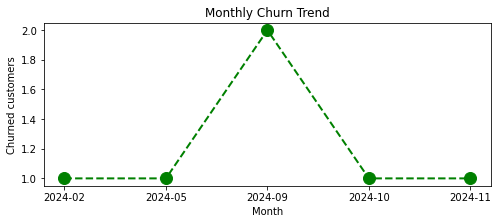

In [210]:
 # Monthly Churn Trend( Time serirs KPI)

df_visual['cancellation_month']=df_visual['cancellation_date'].dt.to_period('M') 
#df_visual['cancellation_date']
churn_trend=df_visual[df_visual['churn_flag']==1].groupby('cancellation_month').size()

plt.figure(figsize=(8,3))



plt.plot(churn_trend.index.astype(str),churn_trend.values,color='green', marker='o', linestyle='dashed',linewidth=2, markersize=12)

plt.title('Monthly Churn Trend')
plt.xlabel('Month')
plt.ylabel('Churned customers')
plt.show()

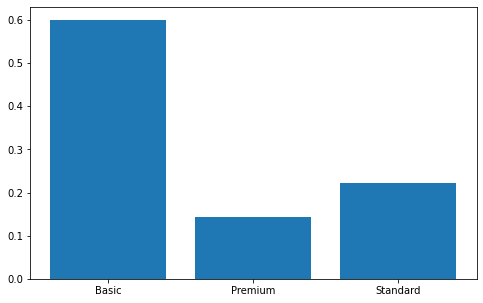

In [215]:
# Churn by plan type
churn_plan=df_visual.groupby('plan_type')['churn_flag'].mean()

colors
plt.figure(figsize=(8,5))
plt.bar(churn_plan.index,churn_plan.values)
plt.show()

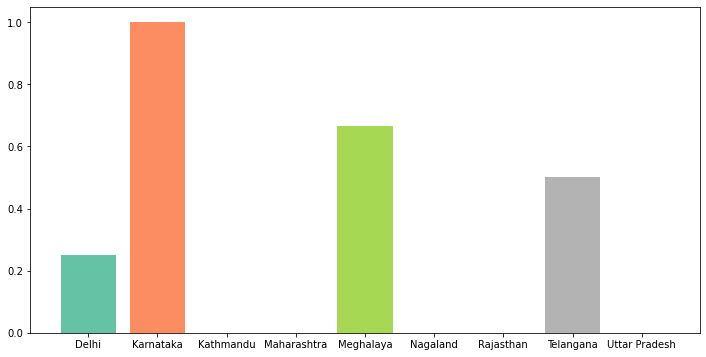

In [219]:
# Churn by state
churn_plan=df_visual.groupby('state')['churn_flag'].mean()
colors=plt.cm.Set2(np.linspace(0,1,len(churn_plan)))
plt.figure(figsize=(12,6))
plt.bar(churn_plan.index,churn_plan.values,color=colors)
plt.show()


In [ ]:
#encoding-conver str to int

In [ ]:
# Heatmap(correlation matrix)


In [208]:
df_visual.columns

Index(['customerid', 'subscription_start_date', 'subscription_type',
       'renewal_date', 'plan_type', 'contract_type', 'cancellation_date',
       'cancellation_reason', 'monthly_charges', 'cltv', 'churn_score',
       'churn_flag', 'customer_name', 'country', 'state', 'gender', 'dob',
       'complaint_date', 'escalations', 'csat_score', 'complaint_count',
       'tenure_days', 'churn_risk', 'cancellation_month'],
      dtype='object')